In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.datasets import load_iris

# Tải tập dữ liệu Iris
iris = load_iris()

# Tạo DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

In [16]:
# Hiển thị 5 dòng đầu tiên
print("--- 5 dòng đầu tiên của dữ liệu ---")
display(df.head())

--- 5 dòng đầu tiên của dữ liệu ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [17]:
print('in dữ liệu ra')
df.info()

in dữ liệu ra
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


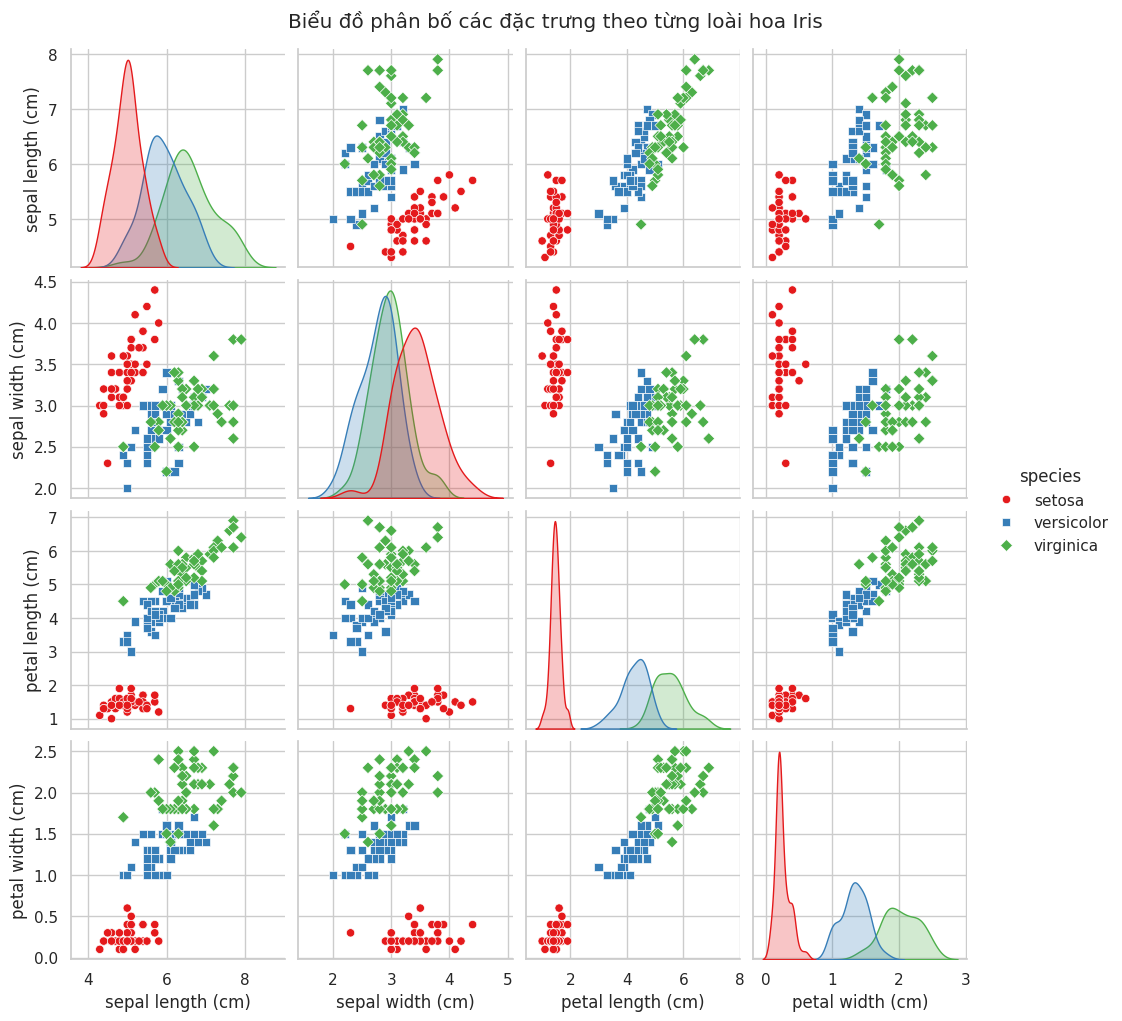

In [18]:
# Trực quan hóa phân bố các loài hoa bằng Pairplot
sns.pairplot(
    df.drop("target", axis=1),
    hue="species",
    palette="Set1",
    markers=["o", "s", "D"]
)

plt.suptitle(
    "Biểu đồ phân bố các đặc trưng theo từng loài hoa Iris",
    y=1.02
)

plt.show()

In [20]:

from sklearn.model_selection import train_test_split

# Khai báo X (đặc trưng) và y (nhãn)
X = iris.data
y = iris.target

# Chia dữ liệu theo tỉ lệ 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Kích thước tập Train (X_train): {X_train.shape}")
print(f"Kích thước tập Test (X_test): {X_test.shape}")

Kích thước tập Train (X_train): (120, 4)
Kích thước tập Test (X_test): (30, 4)


In [21]:
from sklearn.naive_bayes import GaussianNB

# Khởi tạo mô hình Gaussian Naive Bayes
model = GaussianNB()

# Huấn luyện mô hình
model.fit(X_train, y_train)

print("Đã huấn luyện xong mô hình Gaussian Naive Bayer")

Đã huấn luyện xong mô hình Gaussian Naive Bayer


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dự đoán nhãn trên tập Test
y_pred = model.predict(X_test)

# Tính độ chính xác (Accuracy)
acc = accuracy_score(y_test, y_pred)

print(f"Độ chính xác (Accuracy) trên tập Test: {acc * 100:.2f}%\n")

Độ chính xác (Accuracy) trên tập Test: 96.67%



In [23]:
# In report (Precision, Recall, F1-Score)
print("--- Báo cáo chi tiết (Classification Report) ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

--- Báo cáo chi tiết (Classification Report) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



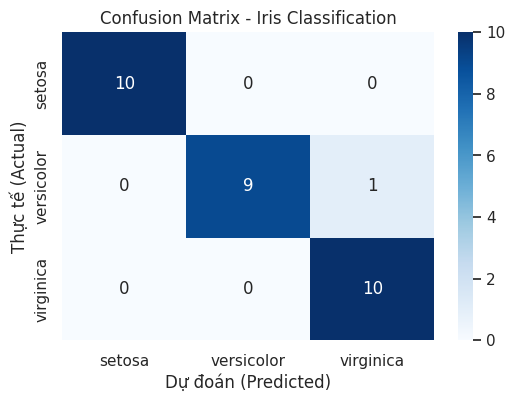

In [24]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.title("Confusion Matrix - Iris Classification")

plt.show()

In [25]:
!pip install gradio

In [69]:
import gradio as gr

# Huấn luyện mô hình Naive Bayes trên toàn bộ dữ liệu Iris
iris = load_iris()
X = iris.data
y = iris.target

model = GaussianNB()
model.fit(X, y)

# Dictionary chứa link hình ảnh đại diện cho từng loài hoa
species_images = {
    "setosa": "/content/drive/MyDrive/AIL_hoaaa/1790997729001_3952417606131047985_g7586510699556540576_e3084215504a0fedd6d558ea6c050578.jpg",

    "versicolor": "/content/drive/MyDrive/AIL_hoaaa/1790997729290_3952417606131047985_g7586510699556540576_c7e6b309ff702208f70fd86757b5f52c.jpg",

    "virginica": "/content/drive/MyDrive/AIL_hoaaa/1790997729742_3952417606131047985_g7586510699556540576_ed6311813705d3b92fff61f0683d18c0.jpg"
}


In [70]:
import gradio as gr
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Hàm xử lý dự đoán cho Gradio
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    # Đưa dữ liệu đầu vào thành numpy array
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Dự đoán lớp và xác suất
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]

    predicted_species = iris.target_names[prediction]

    # Tạo dictionary chứa xác suất của cả 3 lớp
    prob_dict = {
        iris.target_names[i].capitalize(): float(probabilities[i])
        for i in range(len(iris.target_names))
    }

    # Lấy hình ảnh tương ứng với kết quả dự đoán
    img_url = species_images[predicted_species]

    # Kết quả chuỗi chữ hiển thị
    result_text = f"Mô hình dự đoán: {predicted_species.upper()}"

    return result_text, prob_dict, img_url

# Thiết lập giao diện Gradio
demo = gr.Interface(
    fn=predict_iris,
    inputs=[
        gr.Slider(minimum=4.0, maximum=8.0, value=5.1, step=0.1, label="Sepal Length (cm)"),
        gr.Slider(minimum=2.0, maximum=5.0, value=3.5, step=0.1, label="Sepal Width (cm)"),
        gr.Slider(minimum=1.0, maximum=7.0, value=1.4, step=0.1, label="Petal Length (cm)"),
        gr.Slider(minimum=0.1, maximum=3.0, value=0.2, step=0.1, label="Petal Width (cm)")
    ],
    outputs=[
        gr.Textbox(label="Kết quả nhận diện"),
        gr.Label(num_top_classes=3, label="Xác suất tương ứng"),
        gr.Image(label="Hình ảnh loài hoa")
    ],
    title="🌸 Nhận diện loài hoa Iris (Gaussian Naive Bayes)",
    description="Kéo chọn kích thước đài hoa và cánh hoa để xem mô hình phân loại và hiển thị ảnh hoa tương ứng."
)

# Khởi chạy giao diện
demo.launch()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45a58397b50bffae06.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [72]:
import gradio as gr
import numpy as np

# Hàm xử lý dự đoán cho Gradio
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    predicted_species = iris.target_names[prediction]

    prob_dict = {
        iris.target_names[i].capitalize(): float(probabilities[i])
        for i in range(len(iris.target_names))
    }

    img_url = species_images.get(predicted_species, None)
    result_text = f"🌈 Mô hình dự đoán: {predicted_species.upper()} ✨"

    return result_text, prob_dict, img_url

# CSS phong cách LGBT / Pride (Rainbow Palette)
pride_css = """
/* Đường viền dải cờ cầu vồng ở trên cùng của trang web */
.gradio-container {
    border-top: 8px solid !important;
    border-image: linear-gradient(90deg, #E40303, #FF8C00, #FFED00, #008026, #004CFF, #732982) 1 !important;
    background: #fdfbfe !important;
}

/* Tiêu đề hiệu ứng chữ chuyển màu cầu vồng lung linh */
h1 {
    background: linear-gradient(90deg, #E40303, #FF8C00, #E5C100, #008026, #004CFF, #732982);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-weight: 900 !important;
    text-align: center;
}

/* Tùy biến nút Submit/Clear rực rỡ sắc màu */
button.primary {
    background: linear-gradient(90deg, #E40303, #FF8C00, #008026, #004CFF, #732982) !important;
    color: white !important;
    font-weight: bold !important;
    border: none !important;
    box-shadow: 0 4px 12px rgba(228, 3, 3, 0.25) !important;
}

/* Đổi màu nhấn cho các thanh trượt và khối hiển thị */
.progress-bar, .label-container {
    background: linear-gradient(90deg, #FF69B4, #9B51E0) !important;
}
"""

# Thiết lập giao diện Gradio
demo = gr.Interface(
    fn=predict_iris,
    inputs=[
        gr.Slider(minimum=4.0, maximum=8.0, value=5.1, step=0.1, label="🌸 Sepal Length (cm)"),
        gr.Slider(minimum=2.0, maximum=5.0, value=3.5, step=0.1, label="🌺 Sepal Width (cm)"),
        gr.Slider(minimum=1.0, maximum=7.0, value=1.4, step=0.1, label="🌼 Petal Length (cm)"),
        gr.Slider(minimum=0.1, maximum=3.0, value=0.2, step=0.1, label="🌻 Petal Width (cm)")
    ],
    outputs=[
        gr.Textbox(label="Kết quả nhận diện"),
        gr.Label(num_top_classes=3, label="Xác suất tương ứng"),
        gr.Image(label="Hình ảnh loài hoa", height=260, width=260)
    ],
    title="🌈 Iris Classifier - Pride Rainbow Edition 🏳️‍🌈",
    description="Kéo chọn kích thước đài hoa và cánh hoa để mô hình phân loại và hiển thị hình ảnh.",
    css=pride_css
)

# Khởi chạy giao diện
demo.launch()

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  super().__init__(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://576146e9f8010eb2da.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [96]:
!pip install -q streamlit

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
%%writefile /content/app.py
import os
import numpy as np
import pandas as pd
import streamlit as st

from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Cấu hình trang
st.set_page_config(
    page_title="Demo Phân Loại Hoa Iris",
    page_icon="🌸",
    layout="wide"
)


# Tải dữ liệu, huấn luyện mô hình và tính Accuracy
@st.cache_resource
def load_resources():
    iris = load_iris()
    X = iris.data
    y = iris.target

    # Mô hình dự đoán chính được huấn luyện trên toàn bộ dữ liệu
    model = GaussianNB()
    model.fit(X, y)

    # Mô hình phụ để tính độ chính xác trên tập Test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    test_model = GaussianNB()
    test_model.fit(X_train, y_train)
    test_accuracy = accuracy_score(
        y_test,
        test_model.predict(X_test)
    )

    return iris, model, test_accuracy


iris, model, test_accuracy = load_resources()


# Đường dẫn ảnh trong Google Drive
IMAGE_DIR = "/content/drive/MyDrive/AIL_hoaaa"

species_images = {
    "setosa": os.path.join(
        IMAGE_DIR,
        "1790997729001_3952417606131047985_g7586510699556540576_e3084215504a0fedd6d558ea6c050578.jpg"
    ),
    "versicolor": os.path.join(
        IMAGE_DIR,
        "1790997729290_3952417606131047985_g7586510699556540576_c7e6b309ff702208f70fd86757b5f52c.jpg"
    ),
    "virginica": os.path.join(
        IMAGE_DIR,
        "1790997729742_3952417606131047985_g7586510699556540576_ed6311813705d3b92fff61f0683d18c0.jpg"
    )
}


# Tiêu đề và hướng dẫn
st.title("🌸 Demo Phân Loại Hoa Iris Dataset")
st.subheader("Mô hình Gaussian Naive Bayes")
st.write(
    "Điều chỉnh các thông số của hoa ở cột bên trái, "
    "sau đó nhấn **Dự đoán ngay**."
)


# Thông tin mô hình
with st.sidebar:
    st.header("Thông tin mô hình")
    st.write("**Thuật toán:** Gaussian Naive Bayes")
    st.write("**Dữ liệu:** Iris Dataset")
    st.write(f"**Accuracy tập Test:** {test_accuracy:.2%}")
    st.caption("Chia dữ liệu 80/20, random_state=42, stratify=y.")


# Lưu kết quả để không mất sau khi giao diện chạy lại
if "iris_result" not in st.session_state:
    st.session_state.iris_result = None


# Bố cục 2 cột
input_col, result_col = st.columns(2)

with input_col:
    st.header("① Thông số đầu vào")

    with st.form("iris_form"):
        sepal_length = st.slider(
            "Chiều dài lá đài (Sepal Length - cm)",
            min_value=4.0,
            max_value=8.0,
            value=5.1,
            step=0.1
        )

        sepal_width = st.slider(
            "Chiều rộng lá đài (Sepal Width - cm)",
            min_value=2.0,
            max_value=4.5,
            value=3.5,
            step=0.1
        )

        petal_length = st.slider(
            "Chiều dài cánh hoa (Petal Length - cm)",
            min_value=1.0,
            max_value=7.0,
            value=1.4,
            step=0.1
        )

        petal_width = st.slider(
            "Chiều rộng cánh hoa (Petal Width - cm)",
            min_value=0.1,
            max_value=2.5,
            value=0.2,
            step=0.1
        )

        submitted = st.form_submit_button("Dự đoán ngay")

    if submitted:
        input_data = np.array([[
            sepal_length,
            sepal_width,
            petal_length,
            petal_width
        ]])

        prediction = model.predict(input_data)[0]
        probabilities = model.predict_proba(input_data)[0]

        st.session_state.iris_result = {
            "species": iris.target_names[prediction],
            "probabilities": probabilities
        }


with result_col:
    st.header("② Kết quả phân loại")

    result = st.session_state.iris_result

    if result is None:
        st.info("Nhập thông số bên trái rồi nhấn **Dự đoán ngay**.")
    else:
        species = result["species"]
        confidence = float(max(result["probabilities"]))

        st.success(f"Loài hoa dự đoán: **{species.upper()}**")
        st.write(f"Độ tin cậy: **{confidence:.2%}**")

        image_path = species_images[species]

        if os.path.isfile(image_path):
            st.image(
                image_path,
                caption=f"Iris {species.title()}",
                width="stretch"
            )
        else:
            st.warning(
                f"Không tìm thấy ảnh: {image_path}. "
                "Hãy kiểm tra tên thư mục và tên file trong Google Drive."
            )

        st.subheader("Xác suất của từng loài")

        for name, probability in zip(
            iris.target_names,
            result["probabilities"]
        ):
            st.write(f"**{name.title()}** — {probability:.2%}")
            st.progress(float(probability))


# Bonus: xem bảng dữ liệu Iris
with st.expander("Xem bảng dữ liệu Iris"):
    iris_df = pd.DataFrame(
        iris.data,
        columns=iris.feature_names
    )
    iris_df["Loài hoa"] = [
        iris.target_names[target]
        for target in iris.target
    ]

    st.dataframe(iris_df, width="stretch")

Overwriting /content/app.py


In [98]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared
!chmod +x /usr/local/bin/cloudflared

In [99]:
!streamlit run /content/app.py --server.address 0.0.0.0 --server.port 8501 > /content/streamlit.log 2>&1 &

In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-10-03T09:46:00Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-10-03T09:46:00Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-10-03T09:46:04Z INF +--------------------------------------------------------------------------------------------+
2026-10-03T09:46:04Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-10-03T09:46:04Z INF |  https://pond-kidney-alphabetical-midnight.trycloudfla